In [10]:
!pip install folium

  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)

   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [103]:

df = pd.read_csv(r'C:\Users\kisho\Downloads\ipl-analysis\data\matches_data.csv')
print(df.shape)
print(df.columns.tolist())

(1169, 23)
['match_id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'result']


In [113]:
#prevent duplicates
venue_fixes = {
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association Is Bindra Stadium': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association Is Bindra Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association Is Bindra Stadium, Mohali, Chandigarh': 'Punjab Cricket Association Stadium',
    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',
    'Subrata Roy Sahara Stadium': 'Maharashtra Cricket Association Stadium',
    'Dr. Y.S. Rajasekhara Reddy Aca-Vdca Cricket Stadium': 'ACA-VDCA Stadium',
    'Aca-Vdca Stadium': 'ACA-VDCA Stadium',
    'Dr. Y.S. Rajasekhara Reddy Aca-Vdca Cricket Stadium, Visakhapatnam': 'ACA-VDCA Stadium',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Ma Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    'Ma Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'Ma Chidambaram Stadium': 'MA Chidambaram Stadium',
    'Dr Dy Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Dr Dy Patil Sports Academy': 'Dr DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Narendra Modi Stadium, Ahmedabad': 'Narendra Modi Stadium',
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium',
    'Zayed Cricket Stadium, Abu Dhabi': 'Sheikh Zayed Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow': 'Ekana Cricket Stadium',
    'Barsapara Cricket Stadium, Guwahati': 'Barsapara Cricket Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'Himachal Pradesh Cricket Association Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur': 'Maharaja Yadavindra Singh International Cricket Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh': 'Maharaja Yadavindra Singh International Cricket Stadium',
    'Vidarbha Cricket Association Stadium, Jamtha': 'Vidarbha Cricket Association Stadium',
    'Jsca International Stadium Complex': 'JSCA International Stadium Complex',
}

df['venue'] = df['venue'].replace(venue_fixes)
print(df['venue'].unique())
print(f"Total unique venues: {df['venue'].nunique()}")

['M Chinnaswamy Stadium' 'Rajiv Gandhi International Stadium'
 'Maharashtra Cricket Association Stadium'
 'Saurashtra Cricket Association Stadium' 'Holkar Cricket Stadium'
 'Wankhede Stadium' 'Eden Gardens' 'Feroz Shah Kotla'
 'Punjab Cricket Association IS Bindra Stadium, Mohali' 'Green Park'
 'Punjab Cricket Association IS Bindra Stadium' 'MA Chidambaram Stadium'
 'Sawai Mansingh Stadium' 'Arun Jaitley Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Sheikh Zayed Stadium' 'Dubai International Cricket Stadium'
 'Sharjah Cricket Stadium' 'MA Chidambaram Stadium, Chepauk, Chennai'
 'Narendra Modi Stadium' 'Brabourne Stadium'
 'Dr DY Patil Sports Academy, Mumbai'
 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh'
 'Ekana Cricket Stadium' 'Barsapara Cricket Stadium'
 'Himachal Pradesh Cricket Association Stadium'
 'Maharaja Yadavindra Singh International Cricket Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam'
 'Punjab Cricke

In [111]:
#sanity check
print(df['toss_winner'].unique())
print(df['match_winner'].unique())
print(df['toss_decision'].unique())

['Royal Challengers Bengaluru' 'Rising Pune Supergiants'
 'Kolkata Knight riders' 'Punjab Kings' 'Sun risers Hyderabad'
 'Mumbai Indians' 'Gujarat Lions' 'Delhi Capitals' 'Chennai Super Kings'
 'Rajasthan Royals' 'Gujarat Titans' 'Lucknow Super Giants'
 'Kochi tuskers Kerala' 'Pune warriors']
['Kolkata Knight riders' 'Sun risers Hyderabad' 'Rising Pune Supergiants'
 'Punjab Kings' 'Royal Challengers Bengaluru' 'Mumbai Indians'
 'Delhi Capitals' 'Gujarat Lions' 'Chennai Super Kings' 'Rajasthan Royals'
 'Gujarat Titans' 'Lucknow Super Giants' 'Pune warriors'
 'Kochi tuskers Kerala']
['field' 'bat']


In [114]:
df['toss_match_win'] = df['toss_winner'] == df['match_winner']
win_rate = df['toss_match_win'].mean()
print(f"Toss winner wins match: {win_rate:.1%}")

Toss winner wins match: 51.6%


In [118]:
## Key finding 1
#Winning the toss only translates to a match win 51.6% of the time 
#barely better than chance. This suggests the toss is less influential
#than popular opinion suggests.


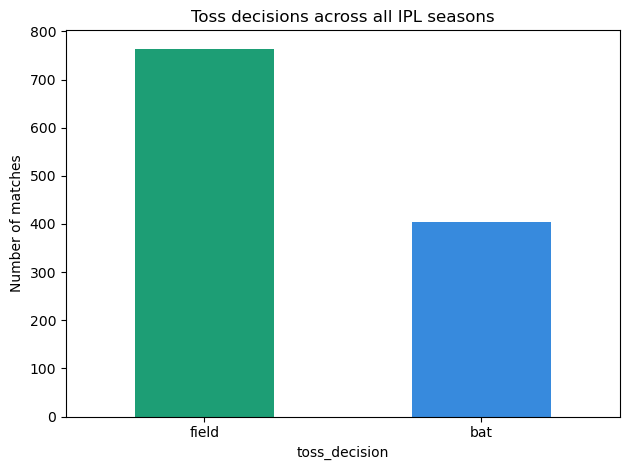

In [119]:
decision_counts = df['toss_decision'].value_counts()
decision_counts.plot(kind='bar', color=['#1D9E75','#378ADD'])
plt.title('Toss decisions across all IPL seasons')
plt.ylabel('Number of matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('toss_decisions.png', dpi=150)
plt.show()

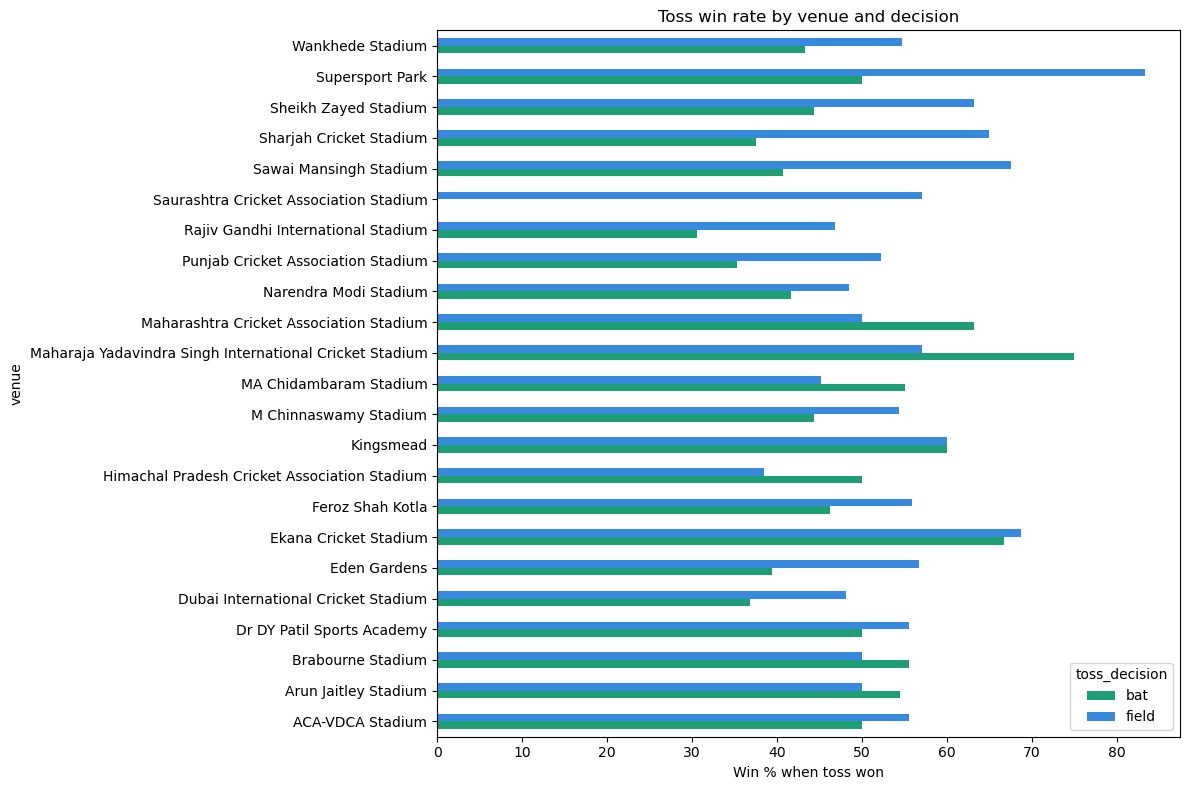

In [34]:
pivot = venue_toss.pivot(index='venue', 
                          columns='toss_decision', 
                          values='win_pct')
pivot.plot(kind='barh', figsize=(12, 8), 
           color=['#1D9E75','#378ADD'])
plt.xlabel('Win % when toss won')
plt.title('Toss win rate by venue and decision')
plt.tight_layout()
plt.savefig('venue_toss_winrate.png', dpi=150)
plt.show()

In [120]:
venue_coords = {
    'M Chinnaswamy Stadium': (12.9789, 77.5993),
    'Rajiv Gandhi International Stadium': (17.4040, 78.5516),
    'Maharashtra Cricket Association Stadium': (18.6488, 73.7254),
    'Saurashtra Cricket Association Stadium': (22.2920, 70.7823),
    'Holkar Cricket Stadium': (22.7196, 75.8577),
    'Wankhede Stadium': (18.9388, 72.8252),
    'Eden Gardens': (22.5645, 88.3433),
    'Feroz Shah Kotla': (28.6368, 77.2448),
    'Arun Jaitley Stadium': (28.6368, 77.2448),
    'Punjab Cricket Association Stadium': (30.6814, 76.8154),
    'Green Park': (26.4637, 80.3290),
    'MA Chidambaram Stadium': (13.0628, 80.2796),
    'Sawai Mansingh Stadium': (26.9124, 75.8040),
    'ACA-VDCA Stadium': (17.7231, 83.2032),
    'Sheikh Zayed Stadium': (24.4358, 54.4749),
    'Dubai International Cricket Stadium': (25.0387, 55.2219),
    'Sharjah Cricket Stadium': (25.3315, 55.3894),
    'Narendra Modi Stadium': (23.0900, 72.0847),
    'Brabourne Stadium': (18.9322, 72.8264),
    'Dr DY Patil Sports Academy': (19.0435, 73.0169),
    'Ekana Cricket Stadium': (26.8505, 80.9462),
    'Barsapara Cricket Stadium': (26.1445, 91.7362),
    'Himachal Pradesh Cricket Association Stadium': (32.2190, 76.3234),
    'Maharaja Yadavindra Singh International Cricket Stadium': (30.6942, 76.7521),
    'Vidarbha Cricket Association Stadium': (21.1762, 79.0077),
    'JSCA International Stadium Complex': (23.3441, 85.3096),
    'Newlands': (-33.9044, 18.4244),
    "St George'S Park": (-33.9608, 25.6022),
    'Kingsmead': (-29.8587, 31.0218),
    'Supersport Park': (-25.7479, 28.2293),
    'Buffalo Park': (-32.9591, 27.8774),
    'New Wanderers Stadium': (-26.1714, 28.0544),
    'De Beers Diamond Oval': (-28.7282, 24.7499),
    'Outsurance Oval': (-29.1078, 26.2619),
    'Nehru Stadium': (11.0017, 76.9673),
    'Barabati Stadium': (20.4625, 85.8830),
    'Shaheed Veer Narayan Singh International Stadium': (21.2787, 81.6736),
}

In [121]:
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)
tooltip=f"{venue} ({win_pct:.1f}%)"


for venue, (lat, lon) in venue_coords.items():
    subset = df[df['venue'] == venue]
    if len(subset) == 0:
        continue
    
    top_decision = subset['toss_decision'].mode()[0]
    win_pct = subset['toss_match_win'].mean() * 100
    total = len(subset)
    color = 'green' if top_decision == 'field' else 'blue'
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{venue}</b><br>"
            f"Matches: {total}<br>"
            f"Preferred toss: {top_decision}<br>"
            f"Toss win rate: {win_pct:.1f}%",
            max_width=200
        )
    ).add_to(m)
    

m.save('ipl_venues.html')
print("open this html file for map view")

open this html file for map view


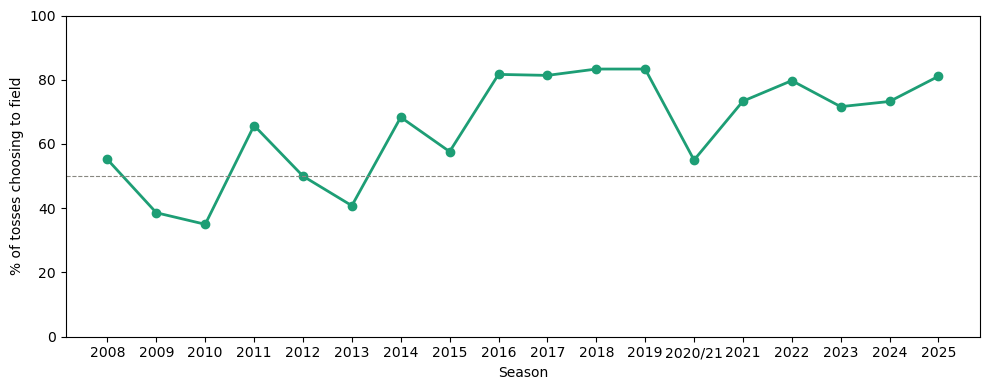

In [122]:
season_trend = df.groupby('season')['toss_decision'].apply(
    lambda x: (x == 'field').mean() * 100
).reset_index()
season_trend.columns = ['season', 'field_pct']

plt.figure(figsize=(10, 4))
plt.plot(season_trend['season'], season_trend['field_pct'], 
         marker='o', color='#1D9E75', linewidth=2)
plt.axhline(50, linestyle='--', color='#888780', linewidth=0.8)
plt.xlabel('Season')
plt.ylabel('% of tosses choosing to field')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('toss_trend.png', dpi=500)

In [ ]:
The trend in choosing to field has been increasing gradually. 
The sudden "dip" that you see in 2020/21 season is because of the season being conducted in UAE due to COVID-19
#UAE pitches are often very dry condition making it easy for bowling later.

In [123]:
venue_advantage = df.groupby('venue')['toss_match_win'].agg(['mean', 'count'])
venue_advantage['mean'] = (venue_advantage['mean'] * 100).round(1)
venue_advantage.columns = ['win_pct', 'matches']

In [124]:
venue_advantage = venue_advantage[venue_advantage['matches'] >= 25]

In [125]:
decision_analysis = df.groupby(['venue', 'toss_decision'])['toss_match_win'].mean().unstack()
decision_analysis = (decision_analysis * 100).round(1)

In [126]:
venue_counts = df['venue'].value_counts()
valid_venues = venue_counts[venue_counts >= 25].index
decision_analysis_filtered = decision_analysis.loc[valid_venues]

In [127]:
top_advantage = venue_advantage.sort_values(by='win_pct', ascending=False).head(5)
least_advantage = venue_advantage.sort_values(by='win_pct').head(5)

In [128]:
print(top_advantage) #venues where the toss winning teams proceeded to win the match more often

                                         win_pct  matches
venue                                                    
Sharjah Cricket Stadium                     57.1       28
Sawai Mansingh Stadium                      56.2       64
Maharashtra Cricket Association Stadium     54.9       51
Sheikh Zayed Stadium                        54.1       37
M Chinnaswamy Stadium                       53.5       99


In [129]:
print(least_advantage) #venues where winning the toss was not an advantage

                                          win_pct  matches
venue                                                     
Rajiv Gandhi International Stadium           39.8       83
Dubai International Cricket Stadium          43.5       46
Punjab Cricket Association Stadium           45.7       35
Narendra Modi Stadium                        46.7       45
MA Chidambaram Stadium, Chepauk, Chennai     47.1       34


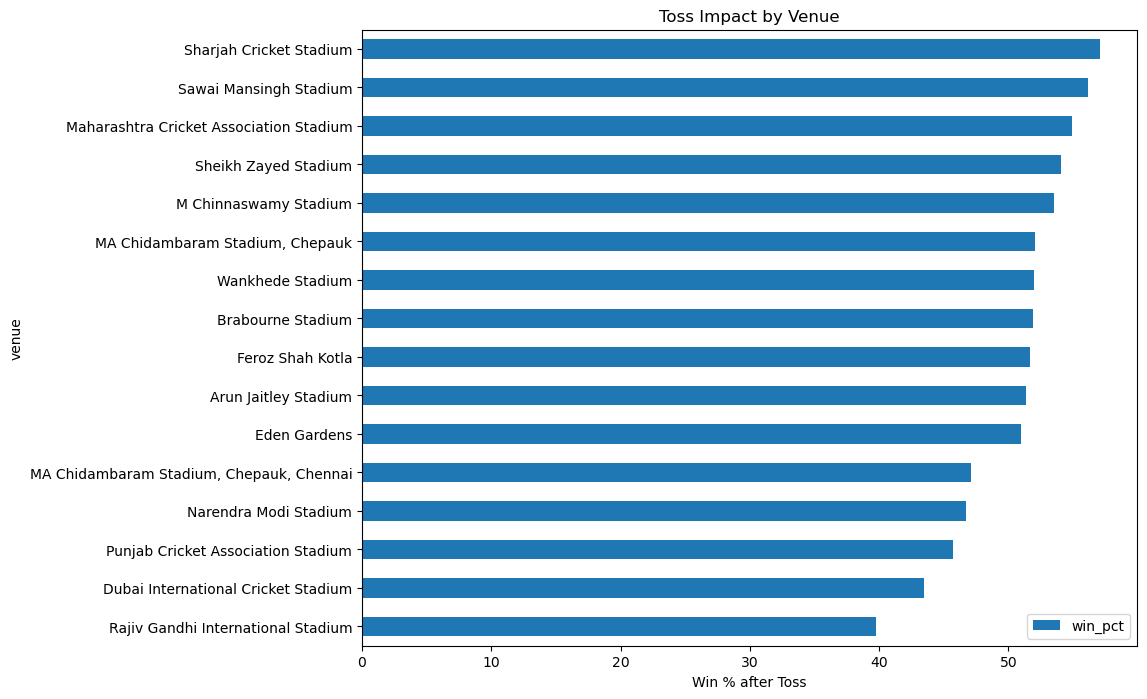

In [130]:
import matplotlib.pyplot as plt

venue_advantage.sort_values('win_pct').plot(
    kind='barh', y='win_pct', figsize=(10,8)
)
plt.title("Toss Impact by Venue")
plt.xlabel("Win % after Toss")
plt.show()

In [131]:
from scipy.stats import ttest_1samp

stat, p = ttest_1samp(df['toss_match_win'], 0.5)
print(p)

0.27936629275803687


In [132]:
print(decision_analysis_filtered) 
# % of teams that chose a decision(to bat/to field) and went on to win the match.
# for example 44.4% of teams who chose batting won in M chinnaswamy stadium.

toss_decision                              bat  field
venue                                                
Wankhede Stadium                          43.3   54.7
Eden Gardens                              39.4   56.7
M Chinnaswamy Stadium                     44.4   54.4
Rajiv Gandhi International Stadium        30.6   46.8
Sawai Mansingh Stadium                    40.7   67.6
Feroz Shah Kotla                          46.2   55.9
Maharashtra Cricket Association Stadium   63.2   50.0
MA Chidambaram Stadium, Chepauk           61.8   28.6
Dubai International Cricket Stadium       36.8   48.1
Narendra Modi Stadium                     41.7   48.5
Arun Jaitley Stadium                      54.5   50.0
Sheikh Zayed Stadium                      44.4   63.2
Punjab Cricket Association Stadium        35.7   52.4
MA Chidambaram Stadium, Chepauk, Chennai  38.5   52.4
Sharjah Cricket Stadium                   37.5   65.0
Brabourne Stadium                         55.6   50.0


In [133]:
filtered_df = df[df['venue'].isin(valid_venues)]
decision_pct = (
    filtered_df.groupby(['venue', 'toss_decision'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack()
    .round(1)
)
print(decision_pct)
# % of toss decision taken by teams in that venue
# that is in MA Chidambaram stadium teams have chosen to bat 53.8% of times.


toss_decision                              bat  field
venue                                                
Arun Jaitley Stadium                      29.7   70.3
Brabourne Stadium                         33.3   66.7
Dubai International Cricket Stadium       41.3   58.7
Eden Gardens                              33.0   67.0
Feroz Shah Kotla                          43.3   56.7
M Chinnaswamy Stadium                      9.1   90.9
MA Chidambaram Stadium, Chepauk           70.8   29.2
MA Chidambaram Stadium, Chepauk, Chennai  38.2   61.8
Maharashtra Cricket Association Stadium   37.3   62.7
Narendra Modi Stadium                     26.7   73.3
Punjab Cricket Association Stadium        40.0   60.0
Rajiv Gandhi International Stadium        43.4   56.6
Sawai Mansingh Stadium                    42.2   57.8
Sharjah Cricket Stadium                   28.6   71.4
Sheikh Zayed Stadium                      48.6   51.4
Wankhede Stadium                          24.0   76.0


In [134]:
decision_win_pct = (
    filtered_df.groupby(['venue', 'toss_decision'])['toss_match_win']
    .mean()
    .unstack() * 100
).round(1)
decision_choice_pct = (
    filtered_df.groupby(['venue', 'toss_decision'])
    .size()
    .unstack()
    .apply(lambda x: x / x.sum() * 100, axis=1)
    .round(1)
)
decision_win_pct, decision_choice_pct = decision_win_pct.align(decision_choice_pct)

In [135]:
gap = decision_win_pct - decision_choice_pct

In [136]:
gap = gap.dropna()

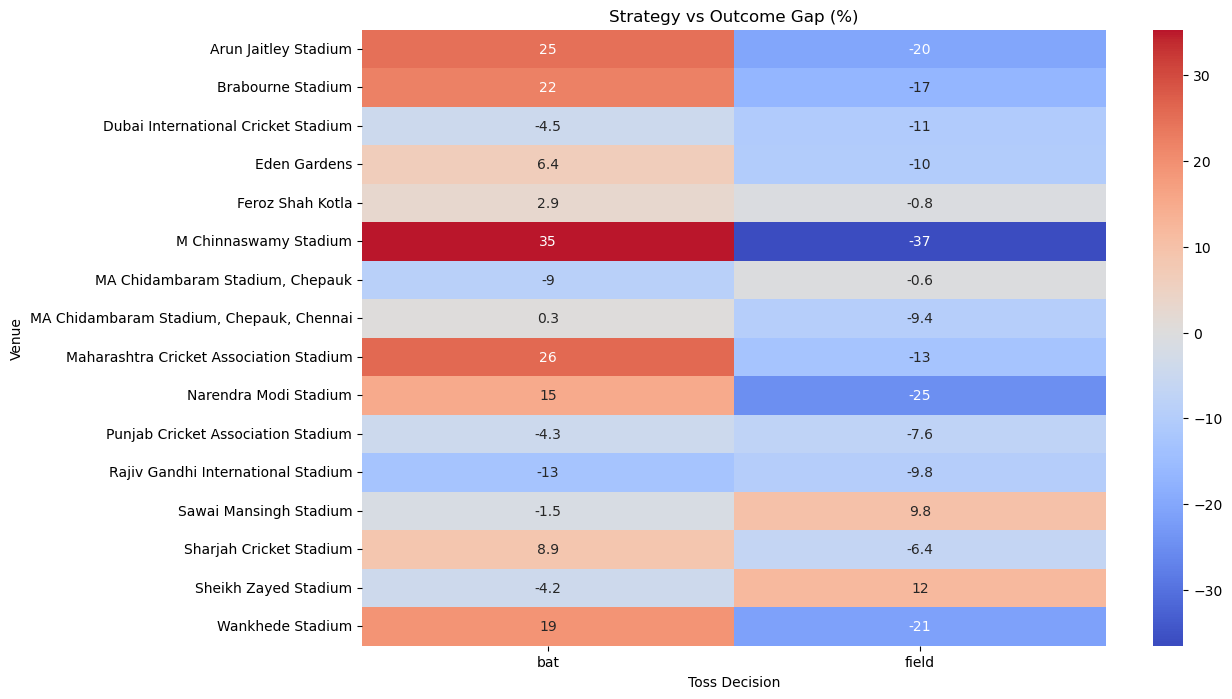

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(gap, annot=True, cmap='coolwarm', center=0)

plt.title("Strategy vs Outcome Gap (%)")
plt.xlabel("Toss Decision")
plt.ylabel("Venue")
plt.show()

In [ ]:
The above Heatmap shows us the gap between the actual win percentage and percentage of times that decision
was taken.
#That is in Narendra modi stadium which shows bat +15 teams teams have underutilised batting first.

In [138]:
toss_advantage = venue_advantage.sort_values(by='win_pct', ascending=False)
print(toss_advantage)


                                          win_pct  matches
venue                                                     
Sharjah Cricket Stadium                      57.1       28
Sawai Mansingh Stadium                       56.2       64
Maharashtra Cricket Association Stadium      54.9       51
Sheikh Zayed Stadium                         54.1       37
M Chinnaswamy Stadium                        53.5       99
MA Chidambaram Stadium, Chepauk              52.1       48
Wankhede Stadium                             52.0      125
Brabourne Stadium                            51.9       27
Feroz Shah Kotla                             51.7       60
Arun Jaitley Stadium                         51.4       37
Eden Gardens                                 51.0      100
MA Chidambaram Stadium, Chepauk, Chennai     47.1       34
Narendra Modi Stadium                        46.7       45
Punjab Cricket Association Stadium           45.7       35
Dubai International Cricket Stadium          43.5       

In [139]:
import numpy as np
p = df['toss_match_win'].mean()
n = df['toss_match_win'].count()

se = np.sqrt(p * (1 - p) / n)
ci_low = p - 1.96 * se
ci_high = p + 1.96 * se

print(p, ci_low, ci_high)

0.5158254918733961 0.4871770388078382 0.5444739449389541


In [140]:
venue_win = df.groupby('venue')['toss_match_win'].mean()
print(venue_win.describe())

count    44.000000
mean      0.545120
std       0.154831
min       0.200000
25%       0.451553
50%       0.525123
75%       0.609091
max       1.000000
Name: toss_match_win, dtype: float64


In [141]:
# p values for individual venues
from scipy.stats import ttest_1samp

for v in valid_venues:
    data = df[df['venue'] == v]['toss_match_win']
    if len(data) >= 25:
        stat, p = ttest_1samp(data, 0.5)
        print(v, p)

Wankhede Stadium 0.6565350364137088
Eden Gardens 0.8426417731724416
M Chinnaswamy Stadium 0.4845165792183358
Rajiv Gandhi International Stadium 0.06163142457481469
Sawai Mansingh Stadium 0.32113603158262577
Feroz Shah Kotla 0.7987025578963619
Maharashtra Cricket Association Stadium 0.48928052529963484
MA Chidambaram Stadium, Chepauk 0.7762106344931364
Dubai International Cricket Stadium 0.3821844483860588
Narendra Modi Stadium 0.6597907603533085
Arun Jaitley Stadium 0.8720386070010138
Sheikh Zayed Stadium 0.6284433696647982
Punjab Cricket Association Stadium 0.6191523108231269
MA Chidambaram Stadium, Chepauk, Chennai 0.7371295774938528
Sharjah Cricket Stadium 0.459740654479437
Brabourne Stadium 0.851574206314888


In [142]:
pref_decision = decision_choice_pct.idxmax(axis=1)
best_decision = decision_win_pct.idxmax(axis=1)


In [143]:
summary = pd.DataFrame({
    'pref_decision': pref_decision,
    'best_decision': best_decision,
    'gap_bat': gap_df['bat'],
    'gap_field': gap_df['field'],
    'p_value': p_values
})

In [144]:
def get_insight(row):
    if row['p_value'] > 0.05:
        if row['pref_decision'] != row['best_decision']:
            return "Suboptimal decision"
        else:
            return "No strong impact"
    else:
        return "Statistically significant"

summary['insight'] = summary.apply(get_insight, axis=1)

In [145]:
summary

,pref_decision,best_decision,gap_bat,gap_field,p_value,insight
Arun Jaitley Stadium,field,bat,24.8,-20.3,0.872039,Suboptimal decision
Brabourne Stadium,field,bat,22.3,-16.7,0.851574,Suboptimal decision
Dr DY Patil Sports Academy,NaN,NaN,23.0,-17.4,0.628443,Suboptimal decision
Dubai International Cricket Stadium,field,field,-4.5,-10.6,0.382184,No strong impact
Eden Gardens,field,field,6.4,-10.3,0.842642,No strong impact
Feroz Shah Kotla,field,field,2.9,-0.8,0.798703,No strong impact
M Chinnaswamy Stadium,field,field,35.3,-36.5,0.484517,No strong impact
MA Chidambaram Stadium,NaN,NaN,1.3,-1.0,0.917197,Suboptimal decision
"MA Chidambaram Stadium, Chepauk",bat,bat,NaN,NaN,NaN,Statistically significant
"MA Chidambaram Stadium, Chepauk, Chennai",field,field,NaN,NaN,NaN,Statistically significant
